# Traveler Insights UPTC 2026 — Grupo 5 (BART)
## Partes 1 y 2: datos, partición, baseline y fine-tuning de BART

Este cuaderno cubre las Fases 1, 2 y 3 de CRISP-ML(Q).
Cada bloque termina con su **QA: riesgo → método → evidencia**.

Requisitos en Kaggle: la competencia como *Input*, *Internet: On* (descarga los modelos) y,
para la Parte 2, *Accelerator: GPU T4 ×2*.

# Parte 1 — Datos, partición y baseline

In [1]:
import os, re, sys, time, json, random, platform, unicodedata, warnings
import numpy as np, pandas as pd, sklearn, matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker, matplotlib.colors
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline, make_union
from sklearn.model_selection import StratifiedKFold, StratifiedGroupKFold, cross_val_predict
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"     # operaciones deterministas en GPU (Parte 2)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

LABELS = ["negativo", "neutral", "positivo"]          # orden fijo en todo el proyecto
LABEL2ID = {l: i for i, l in enumerate(LABELS)}       # negativo=0, neutral=1, positivo=2
CKPT = "vgaraujov/bart-base-spanish"                  # BARTO: checkpoint principal del grupo

# Colores por clase (orden fijo) y tinta de los gráficos
C = {"negativo": "#eb6834", "neutral": "#2a78d6", "positivo": "#1baf7a"}
INK, MUTED, GRID = "#0b0b0b", "#898781", "#e1e0d9"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.edgecolor": "#c3c2b7", "axes.labelcolor": "#52514e", "xtick.color": MUTED,
                     "ytick.color": MUTED, "axes.titlesize": 11, "axes.titleweight": "bold",
                     "axes.titlelocation": "left", "font.size": 9, "figure.facecolor": "#fcfcfb",
                     "axes.facecolor": "#fcfcfb", "legend.frameon": False})

print("python", platform.python_version(), "| pandas", pd.__version__, "| numpy", np.__version__,
      "| sklearn", sklearn.__version__, "| matplotlib", matplotlib.__version__, "| seed", SEED)

python 3.13.15 | pandas 2.3.3 | numpy 2.1.3 | sklearn 1.6.1 | matplotlib 3.10.0 | seed 42


In [2]:
def find_data_dir():
    # Kaggle: /kaggle/input/<competencia>/ ; local: variable DATA_DIR o carpeta actual
    cands = [os.environ.get("DATA_DIR", ""), "."]
    for root, _, files in os.walk("/kaggle/input"):
        if {"train.csv", "test.csv", "submission.csv"} <= set(files):
            cands.insert(0, root)
    for c in cands:
        if c and os.path.exists(os.path.join(c, "train.csv")):
            return c
    raise FileNotFoundError("No encuentro train.csv: adjunta la competencia como Input")

DATA_DIR = find_data_dir()
OUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else os.environ.get("OUT_DIR", ".")
train = pd.read_csv(f"{DATA_DIR}/train.csv")
hold = pd.read_csv(f"{DATA_DIR}/test.csv")          # OJO: viene CON etiqueta
sub = pd.read_csv(f"{DATA_DIR}/submission.csv")     # este es el que se predice (sin etiqueta)
for n, d in [("train", train), ("holdout", hold), ("envio", sub)]:
    d["origen"] = n
todo = pd.concat([train, hold, sub], ignore_index=True)

# QA de esquema: lo que el resto del cuaderno da por cierto
assert todo.ID.is_unique, "hay ID repetidos entre archivos"
assert set(train.Sentimiento) == set(LABELS) and set(hold.Sentimiento) == set(LABELS)
assert sub.Sentimiento.isna().all(), "submission.csv debería venir sin etiqueta"
assert todo.Comentario.notna().all() and (todo.Comentario.str.strip() != "").all()
print({n: len(d) for n, d in [("train", train), ("holdout", hold), ("envio", sub)]}, "| total", len(todo))

{'train': 818, 'holdout': 351, 'envio': 129} | total 1298


## Fase 1 — Comprensión de los datos

**Primera sorpresa:** la descripción dice que `test.csv` no trae etiqueta, pero sí la trae (351 filas).
El archivo que realmente se predice es `submission.csv` (129 filas). El reparto real es 63 % / 27 % / 10 %.
Decisión: `test.csv` se usa como **hold-out local intocable** (no decide hiperparámetros).

Sentimiento  negativo  neutral  positivo  sin etiqueta
origen                                                
envio               0        0         0           129
holdout            10      274        67             0
train              22      639       157             0 

Sentimiento  negativo  neutral  positivo
origen                                  
holdout           2.8     78.1      19.1
train             2.7     78.1      19.2 

Sentimiento  negativo  neutral  positivo
Sitio                                   
Foursquare          0       65       224
Tripadvisor        32      848         0


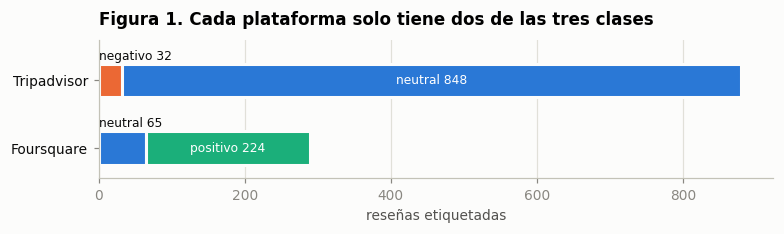

In [3]:
etq = todo[todo.Sentimiento.notna()]
tabla = pd.crosstab(todo.origen, todo.Sentimiento.fillna("sin etiqueta"))
print(tabla, "\n")
print((pd.crosstab(etq.origen, etq.Sentimiento, normalize="index") * 100).round(1), "\n")
print(pd.crosstab(etq.Sitio, etq.Sentimiento))

# Figura 1: clases por plataforma (conteos, train + hold-out)
ct = pd.crosstab(etq.Sitio, etq.Sentimiento).reindex(columns=LABELS, fill_value=0)
fig, ax = plt.subplots(figsize=(7.2, 2.2))
for i, sitio in enumerate(ct.index):
    izq = 0
    for l in LABELS:
        v = ct.loc[sitio, l]
        if v == 0: continue
        ax.barh(i, v, left=izq, color=C[l], height=0.5, edgecolor="#fcfcfb", linewidth=2)
        dentro = v > 120                      # los segmentos pequeños se rotulan encima
        ax.text(izq + v / 2 if dentro else izq, i if dentro else i + 0.36, f"{l} {v}",
                ha="center" if dentro else "left", va="center", fontsize=8,
                color="white" if dentro else INK)
        izq += v
ax.set_yticks(range(len(ct.index))); ax.set_yticklabels(ct.index, color=INK)
ax.set_ylim(-0.45, 1.6)
ax.set_xlabel("reseñas etiquetadas"); ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
ax.set_title("Figura 1. Cada plataforma solo tiene dos de las tres clases", pad=10)
plt.tight_layout(); plt.show()

### Hallazgo central: la etiqueta no es el sentimiento del texto

`Sentimiento` se obtiene aplicando umbrales a `Valoración_num`, que es la **calificación promedio del lugar**
(no de la reseña), y sin normalizar la escala: Foursquare va de 0 a 10 y Tripadvisor de 0 a 5.
La siguiente celda lo verifica.

regla sobre Valoración_num en train: accuracy = 1.0000
regla sobre Valoración_num en holdout: accuracy = 1.0000
lugares (nombre+plataforma): 82 | con más de una etiqueta: 0
los 32 negativos vienen de 2 lugares: {'Ecoparque Laderas de Villeros Coveñas': 4, 'Plaza de Majagual': 28}


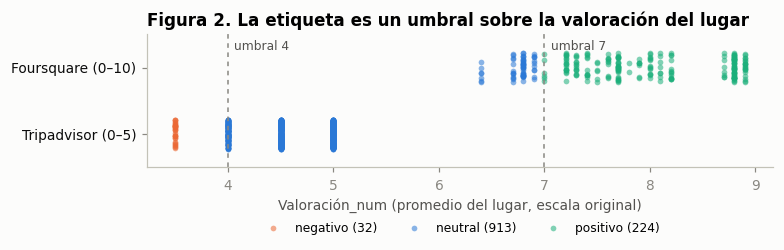

In [4]:
def regla(v):
    return "positivo" if v >= 7 else ("neutral" if v >= 4 else "negativo")

for n, d in [("train", train), ("holdout", hold)]:
    print(f"regla sobre Valoración_num en {n}: accuracy = {(d['Valoración_num'].map(regla) == d.Sentimiento).mean():.4f}")

por_lugar = etq.groupby(["Nombre del lugar", "Sitio"]).Sentimiento.nunique()
print("lugares (nombre+plataforma):", len(por_lugar), "| con más de una etiqueta:", int((por_lugar > 1).sum()))
neg = etq[etq.Sentimiento == "negativo"].groupby("Nombre del lugar").size()
print("los", int(neg.sum()), "negativos vienen de", len(neg), "lugares:", neg.to_dict())

# Figura 2: valoración del lugar vs. etiqueta
fig, ax = plt.subplots(figsize=(7.2, 2.6))
rng = np.random.default_rng(SEED)
for l in LABELS:
    d = etq[etq.Sentimiento == l]
    y = d.Sitio.map({"Foursquare": 1, "Tripadvisor": 0}) + rng.uniform(-0.22, 0.22, len(d))
    ax.scatter(d["Valoración_num"], y, s=14, color=C[l], alpha=0.55, linewidths=0, label=f"{l} ({len(d)})")
for u in (4, 7):
    ax.axvline(u, color=MUTED, lw=1, ls=(0, (3, 3)))
    ax.text(u + 0.06, 1.42, f"umbral {u}", color="#52514e", fontsize=8, va="top")
ax.set_yticks([0, 1]); ax.set_yticklabels(["Tripadvisor (0–5)", "Foursquare (0–10)"], color=INK)
ax.set_ylim(-0.5, 1.5); ax.set_xlabel("Valoración_num (promedio del lugar, escala original)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.32), ncol=3, fontsize=8)
ax.set_title("Figura 2. La etiqueta es un umbral sobre la valoración del lugar")
plt.tight_layout(); plt.show()

**Consecuencias para todo el proyecto**

- Un modelo que lea `Valoración_num` acierta el 100 % sin leer la reseña: eso es un atajo, no análisis de sentimiento.
- Un modelo que solo lee el texto en realidad aprende a reconocer **la plataforma y el lugar** (estilo, longitud,
  nombres propios), no la opinión. Reseñas claramente positivas de Tripadvisor están etiquetadas `neutral`.
- La clase `negativo` son 32 reseñas de 2 lugares: no se puede generalizar a lugares nuevos.
- Esto define el techo del modelo de texto y explica la mayoría de sus "errores" (Fase 4).

             count  mean   std  min   50%   90%    95%    99%    max
Sitio                                                               
Foursquare   321.0   9.0   7.0  1.0   7.0  21.0   25.0   32.0   38.0
Tripadvisor  977.0  52.0  53.0  3.0  35.0  97.0  139.0  294.0  618.0 

             count  mean   std   min   25%   50%   75%    max
Sentimiento                                                  
negativo      32.0  32.6  14.6  16.0  22.8  28.5  37.0   88.0
neutral      913.0  50.0  53.9   2.0  22.0  34.0  58.0  618.0
positivo     224.0   9.2   6.8   1.0   4.0   7.0  12.2   38.0


config.json:   0%|          | 0.00/1.11k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/277 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/4.78M [00:00<?, ?B/s]


Tokens por reseña:
 count    1298.0
mean       73.0
std        82.0
min         4.0
50%        50.0
90%       144.0
95%       203.0
99%       416.0
max       999.0
Name: n_tok, dtype: float64

  max_length  % truncado total  % truncado Foursquare  % truncado Tripadvisor
         32              75.0                   20.6                    92.8
         64              34.8                    1.2                    45.9
        128              13.1                    0.0                    17.4
        192               6.0                    0.0                     8.0
        256               2.9                    0.0                     3.8
        384               1.2                    0.0                     1.5
        512               0.5                    0.0                     0.6

max_length = 384: se trunca el 1.2% de las reseñas (1.5% de Tripadvisor, 0.0% de Foursquare)


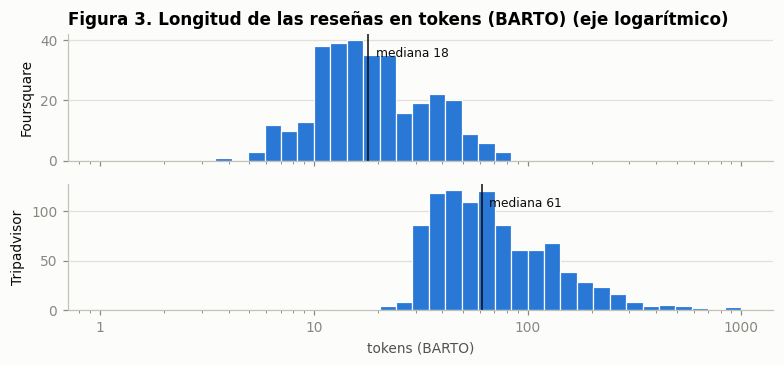

In [5]:
todo["n_car"] = todo.Comentario.str.len()
todo["n_pal"] = todo.Comentario.str.split().str.len()
print(todo.groupby("Sitio").n_pal.describe(percentiles=[.5, .9, .95, .99]).round(0), "\n")
print(todo[todo.Sentimiento.notna()].groupby("Sentimiento").n_pal.describe().round(1))

# Longitud en tokens con el tokenizer del checkpoint (requiere Internet: On en Kaggle)
todo["n_tok"] = np.nan
try:
    from transformers import AutoTokenizer
    tok = AutoTokenizer.from_pretrained(CKPT)
    todo["n_tok"] = [len(x) for x in tok(todo.Comentario.tolist(), add_special_tokens=True)["input_ids"]]
    filas = []
    for m in (32, 64, 128, 192, 256, 384, 512):
        fila = {"max_length": m, "% truncado total": (todo.n_tok > m).mean() * 100}
        for s in ("Foursquare", "Tripadvisor"):
            fila[f"% truncado {s}"] = (todo[todo.Sitio == s].n_tok > m).mean() * 100
        filas.append(fila)
    print("\nTokens por reseña:\n", todo.n_tok.describe(percentiles=[.5, .9, .95, .99]).round(0))
    print("\n", pd.DataFrame(filas).round(1).to_string(index=False))
except Exception as e:
    print("\n[aviso] no se pudo cargar el tokenizer (", type(e).__name__, "): se grafican palabras.")

MAX_LENGTH = 384      # decisión del grupo (Fase 2), tomada con la tabla de truncamiento
if todo.n_tok.notna().all():
    print(f"\nmax_length = {MAX_LENGTH}: se trunca el {(todo.n_tok > MAX_LENGTH).mean():.1%} de las reseñas "
          f"({(todo[todo.Sitio == 'Tripadvisor'].n_tok > MAX_LENGTH).mean():.1%} de Tripadvisor, "
          f"{(todo[todo.Sitio == 'Foursquare'].n_tok > MAX_LENGTH).mean():.1%} de Foursquare)")

col = "n_tok" if todo.n_tok.notna().all() else "n_pal"
unidad = "tokens (BARTO)" if col == "n_tok" else "palabras"
fig, axs = plt.subplots(2, 1, figsize=(7.2, 3.4), sharex=True)
bins = np.logspace(0, np.log10(todo[col].max() + 1), 40)
for ax, s in zip(axs, ("Foursquare", "Tripadvisor")):
    d = todo[todo.Sitio == s][col]
    ax.hist(d, bins=bins, color="#2a78d6", edgecolor="#fcfcfb", linewidth=0.8)
    ax.axvline(d.median(), color=INK, lw=1)
    ax.text(d.median() * 1.08, ax.get_ylim()[1] * 0.82, f"mediana {d.median():.0f}", fontsize=8, color=INK)
    ax.set_ylabel(s, color=INK); ax.yaxis.grid(True, color=GRID); ax.set_axisbelow(True)
axs[0].set_title(f"Figura 3. Longitud de las reseñas en {unidad} (eje logarítmico)")
axs[1].set_xscale("log"); axs[1].set_xlabel(unidad)
axs[1].xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:g}"))
plt.tight_layout(); plt.show()

In [6]:
def normalizar(t):
    # Solo para COMPARAR textos (duplicados). No es el preprocesamiento del modelo.
    t = unicodedata.normalize("NFKC", str(t)).lower()
    return re.sub(r"\s+", " ", t).strip()

todo["clave"] = todo.Comentario.map(normalizar)
dup = todo[todo.duplicated("clave", keep=False)]
g = dup.groupby("clave").agg(n=("ID", "size"), origenes=("origen", lambda s: "+".join(sorted(set(s)))),
                             etiquetas=("Sentimiento", lambda s: sorted(set(s.dropna()))))
print("Duplicados exactos:", len(dup), "filas en", len(g), "grupos")
print(g.origenes.value_counts().to_string())
print("grupos con etiquetas contradictorias:", int((g.etiquetas.str.len() > 1).sum()))

pegadas = todo.Comentario.str.contains(r"[a-záéíóúñ][A-ZÁÉÍÓÚÑ][a-záéíóúñ]")
larga = todo.Comentario.map(lambda t: max((len(w) for w in re.findall(r"[^\W\d_]+", t)), default=0)) >= 18
print("\nPalabras pegadas por el scraping (minúscula+Mayúscula o palabra de 18+ letras):")
print(pd.crosstab(todo.Sitio, pegadas | larga).rename(columns={False: "no", True: "sí"}))
print("ejemplos:", todo[(pegadas | larga) & (todo.Sitio == "Foursquare")].Comentario.head(3).tolist())

print("\nReseñas de 1–2 palabras:", int((todo.n_pal <= 2).sum()))
patrones = {"correo": r"[\w.]+@[\w.]+\.\w+", "teléfono": r"(?<!\d)3\d{2}[\s-]?\d{3}[\s-]?\d{4}(?!\d)",
            "url": r"https?://|www\.", "@usuario": r"(?<!\w)@\w+"}
print("Posibles datos personales:", {k: int(todo.Comentario.str.contains(p).sum()) for k, p in patrones.items()})
ingles = todo.Comentario.str.lower().str.contains(r"\b(?:the|and|was|with|this)\b")
print("Reseñas con inglés:", int(ingles.sum()),
      "| con emoji:", int(todo.Comentario.str.contains(r"[\U0001F300-\U0001FAFF\u2600-\u27BF]").sum()))
todo["año"] = todo.Fecha.str.extract(r"((?:19|20)\d{2})")[0].astype(float)
print("\nAño de la reseña por plataforma (mediana):", todo.groupby("Sitio")["año"].median().to_dict())

lug = {n: set(d["Nombre del lugar"] + "|" + d.Sitio) for n, d in [("train", train), ("holdout", hold), ("envio", sub)]}
print(f"Filas del hold-out cuyo lugar ya está en train: {(hold['Nombre del lugar'] + '|' + hold.Sitio).isin(lug['train']).mean():.1%}")
print(f"Filas del envío cuyo lugar ya está en train u hold-out: {(sub['Nombre del lugar'] + '|' + sub.Sitio).isin(lug['train'] | lug['holdout']).mean():.1%}")

Duplicados exactos: 33 filas en 16 grupos
origenes
train            8
holdout+train    3
envio+holdout    3
envio+train      2
grupos con etiquetas contradictorias: 0

Palabras pegadas por el scraping (minúscula+Mayúscula o palabra de 18+ letras):
Comentario    no  sí
Sitio               
Foursquare   268  53
Tripadvisor  971   6
ejemplos: ['Lahamburguesa de polloy elpatacónDoki, son deliciosos.', 'Si quieres conocer sobre la cultura del Municipio, visita a Evaristo AcostaHuertas, vive por elparque principal.Leer más', 'Llegar se hace un poco dispendioso, pero vale la pena por sus hermosasplayaslimpias,tranquilasy sobretodo solas!']

Reseñas de 1–2 palabras: 24
Posibles datos personales: {'correo': 0, 'teléfono': 0, 'url': 2, '@usuario': 1}
Reseñas con inglés: 4 | con emoji: 36

Año de la reseña por plataforma (mediana): {'Foursquare': 2014.0, 'Tripadvisor': 2018.0}
Filas del hold-out cuyo lugar ya está en train: 97.7%
Filas del envío cuyo lugar ya está en train u hold-out: 98.4%


In [7]:
# Ejemplos ambiguos: el texto dice una cosa y la etiqueta otra
POS = r"excelente|maravillos|incre[ií]ble|espectacular|hermos|recomend|para[ií]so|delicios|encant"
NEG = r"p[eé]sim|suci[oa]|decepci|no recomiendo|insegur|basura|horrible|mal servicio|mala atenci"
txt = etq.Comentario.str.lower()
casos = {"etiqueta neutral con vocabulario claramente positivo": etq[(etq.Sentimiento == "neutral") & txt.str.contains(POS)],
         "etiqueta negativo con vocabulario positivo y sin quejas": etq[(etq.Sentimiento == "negativo") & txt.str.contains(POS) & ~txt.str.contains(NEG)],
         "etiqueta positivo o neutral con vocabulario de queja": etq[(etq.Sentimiento != "negativo") & txt.str.contains(NEG)]}
for nombre, d in casos.items():
    print(f"\n{nombre}: {len(d)} reseñas")
    for _, r in d.sample(min(3, len(d)), random_state=SEED).iterrows():
        print(f"   [{r.Sentimiento} | {r.Sitio} | {r['Valoración']}] {r.Comentario[:150]}")
n_neu = int((etq.Sentimiento == "neutral").sum())
print(f"\nEl {len(casos['etiqueta neutral con vocabulario claramente positivo']) / n_neu:.0%} de las reseñas 'neutral' usa vocabulario claramente positivo.")

# Idioma y variantes
variantes = {"colombianismos / Caribe": r"ch[eé]vere|bacan|sabros|mototax|coste[ñn]|vaina|parcer",
             "rioplatense": r"\bre (?:buen|lind|recomend)|\bche\b|\bvos\b",
             "inglés": r"\b(?:the|and|was|with|this)\b"}
print("\nReseñas por variante:", {k: int(todo.Comentario.str.lower().str.contains(p).sum()) for k, p in variantes.items()})


etiqueta neutral con vocabulario claramente positivo: 571 reseñas
   [neutral | Tripadvisor | 4.5/5] No se puede llegar a Coveñas sin visitar este paraíso natural. A los amantes del avistamiento de aves es un lugar genial.
   [neutral | Tripadvisor | 5.0/5] Excelente servicio, he ido varias veces en 3 años 100% recomendada la empresa Coveñas Diving co. 🎉 Hermosos puntos 💙
   [neutral | Tripadvisor | 4.0/5] La playa para visitar en Mûcura, ya que Tintipán está muy lleno y no hay agua potable para lavado de manos. Muchas moscas, mucho desorden y, a pesar d

etiqueta negativo con vocabulario positivo y sin quejas: 8 reseñas
   [negativo | Tripadvisor | 3.5/5] Es una plaza muy amplia, excelente para cualquier clase de evento de gran multitud, tiene varias diversiones para niños, y gran variedad de comidas.
   [negativo | Tripadvisor | 3.5/5] La imagen de Sincelejo ante Colombia es la Plaza Majagual y las fiestas del 20 de enero, hay muchos vendedores y es muy grande, la brisa que corre es

**QA Fase 1 (riesgo → método → evidencia)**

| Riesgo | Método | Evidencia (celdas de arriba) |
|---|---|---|
| Desbalance | Conteo por clase y por plataforma | 78 % neutral, 19 % positivo, 2,7 % negativo; Figura 1 |
| Ruido / validez de etiqueta | Reconstruir la etiqueta con una regla sobre `Valoración_num` | La regla acierta 100 % en train y hold-out; Figura 2 |
| Fuga train/test | Duplicados exactos entre archivos y solapamiento de lugares | Grupos duplicados entre archivos; casi todas las filas de evaluación son de lugares ya vistos |
| Atajos no lingüísticos | Palabras pegadas, longitud y año por plataforma | El texto delata la plataforma, y la plataforma acota la clase |
| Privacidad | Expresiones regulares de correo, teléfono, URL y @usuario | Sin correos ni teléfonos; hay nombres de pila de guías y empleados |

## Fase 2 — Ingeniería de datos

- **Limpieza mínima:** normalización Unicode y espacios. No se pasa a minúsculas, no se quitan tildes, signos ni emojis:
  el tokenizer subword los maneja y llevan señal. Las palabras pegadas no se separan (se documenta como artefacto).
- **Fuga:** se eliminan de `train` las reseñas cuyo texto también está en el hold-out y se deja un solo ejemplar
  de cada texto repetido, de modo que ningún texto puede quedar a la vez en entrenamiento y validación.
- **Partición:** 5 folds estratificados con semilla fija. Con 22 negativos, una sola partición 80/20 dejaría
  unos 4 negativos en validación: demasiado ruido para decidir algo. Con 5 folds cada negativo se evalúa una vez.
- **Tokenización:** `max_length` = 384 tokens (trunca cerca del 1 % de las reseñas; con 256 sería el 3 % y con 128 el 13 %).
  Subir a 512 solo rescataría otro 0,7 % a cambio de más memoria y tiempo.
  Se trunca al final: se conserva el inicio de la reseña, donde suele estar la valoración general, y el token `</s>`.
- **Desbalance:** pesos de clase inversos a la frecuencia; en BART se prueban como experimento (E3). No se hace
  sobremuestreo porque los 22 negativos vienen de 2 lugares y repetirlos solo reforzaría el atajo.

In [8]:
def limpiar(t):
    t = unicodedata.normalize("NFC", str(t))
    return re.sub(r"\s+", " ", t).strip()

for d in (train, hold, sub):
    d["texto"] = d.Comentario.map(limpiar)
    d["clave"] = d.Comentario.map(normalizar)

antes = len(train)
train = train[~train.clave.isin(set(hold.clave))]
sin_holdout = len(train)
train = train.drop_duplicates("clave", keep="first").reset_index(drop=True)
print(f"train: {antes} -> {len(train)} (se quitan {antes - sin_holdout} reseñas repetidas en el hold-out "
      f"y {sin_holdout - len(train)} repetidas dentro de train)")

N_FOLDS = 5
cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
train["fold"] = -1
for k, (_, va) in enumerate(cv.split(train.texto, train.Sentimiento)):
    train.loc[va, "fold"] = k
FOLDS = [(np.where(train.fold != k)[0], np.where(train.fold == k)[0]) for k in range(N_FOLDS)]

# Aserciones del pipeline
assert (train.fold >= 0).all()
assert train.clave.is_unique, "quedan textos repetidos dentro de train"
neg_fold = train[train.Sentimiento == "negativo"].groupby("fold").size()
assert neg_fold.min() >= 4 and neg_fold.max() - neg_fold.min() <= 1, "los negativos no quedaron repartidos parejo"
assert not set(train.clave) & set(hold.clave), "hay texto compartido entre train y hold-out"
assert set(train.Sentimiento) <= set(LABELS) and set(hold.Sentimiento) <= set(LABELS)
assert train.groupby("fold").Sentimiento.nunique().min() == 3, "algún fold se quedó sin una clase"
assert len(sub) == 129 and sub.ID.is_unique
print(pd.crosstab(train.fold, train.Sentimiento))
print("duplicados que NO se pueden quitar (texto del envío presente en train/hold-out):",
      int(sub.clave.isin(set(train.clave) | set(hold.clave)).sum()), "de", len(sub))
train[["ID", "fold"]].to_csv(f"{OUT_DIR}/folds.csv", index=False)   # los mismos folds para BART

train: 818 -> 806 (se quitan 3 reseñas repetidas en el hold-out y 9 repetidas dentro de train)
Sentimiento  negativo  neutral  positivo
fold                                    
0                   5      126        31
1                   4      126        31
2                   4      125        32
3                   4      125        32
4                   5      125        31
duplicados que NO se pueden quitar (texto del envío presente en train/hold-out): 5 de 129


## Fase 3 — Baseline clásico (no neuronal)

TF-IDF (palabras 1–2 + caracteres 2–5) + Regresión Logística, evaluado en los mismos folds y en el hold-out.
Se reportan también dos referencias que acotan el problema: la clase mayoritaria (piso) y la variante
con metadatos del lugar (muestra cuánto del problema es el atajo).

In [9]:
def modelo_clasico(pesos=None):
    vec = make_union(TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True),
                     TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True))
    return make_pipeline(vec, LogisticRegression(C=10, max_iter=3000, class_weight=pesos, random_state=SEED))

def con_metadatos(d):
    return "Sitio: " + d.Sitio + " | Lugar: " + d["Nombre del lugar"] + " | Valoración: " + d["Valoración"] + " | " + d.texto

def metricas(y, p):
    return {"acc": accuracy_score(y, p), "f1_macro": f1_score(y, p, average="macro", labels=LABELS, zero_division=0)}

variantes = [("B1 TF-IDF+RL, texto", lambda d: d.texto, None),
             ("B2 TF-IDF+RL, texto, pesos de clase", lambda d: d.texto, "balanced"),
             ("B3 TF-IDF+RL, texto+metadatos, pesos", con_metadatos, "balanced")]
filas, pred = [], {}
m = metricas(train.Sentimiento, ["neutral"] * len(train)); h = metricas(hold.Sentimiento, ["neutral"] * len(hold))
filas.append({"modelo": "B0 clase mayoritaria", "acc_cv": m["acc"], "f1_macro_cv": m["f1_macro"],
              "acc_holdout": h["acc"], "f1_macro_holdout": h["f1_macro"], "tiempo_s": 0.0})
for nombre, entrada, pesos in variantes:
    t0 = time.time()
    p_cv = cross_val_predict(modelo_clasico(pesos), entrada(train), train.Sentimiento, cv=FOLDS)
    clf = modelo_clasico(pesos).fit(entrada(train), train.Sentimiento)
    p_ho = clf.predict(entrada(hold)); pred[nombre] = (p_cv, p_ho, clf, entrada)
    m, h = metricas(train.Sentimiento, p_cv), metricas(hold.Sentimiento, p_ho)
    filas.append({"modelo": nombre, "acc_cv": m["acc"], "f1_macro_cv": m["f1_macro"],
                  "acc_holdout": h["acc"], "f1_macro_holdout": h["f1_macro"], "tiempo_s": time.time() - t0})
m = metricas(train.Sentimiento, train["Valoración_num"].map(regla))   # sin entrenamiento: se aplica a todo train
h = metricas(hold.Sentimiento, hold["Valoración_num"].map(regla))
filas.append({"modelo": "R  regla sobre Valoración_num (atajo)", "acc_cv": m["acc"], "f1_macro_cv": m["f1_macro"],
              "acc_holdout": h["acc"], "f1_macro_holdout": h["f1_macro"], "tiempo_s": 0.0})
resultados = pd.DataFrame(filas)
print(resultados.round(4).to_string(index=False))

                               modelo  acc_cv  f1_macro_cv  acc_holdout  f1_macro_holdout  tiempo_s
                 B0 clase mayoritaria  0.7779       0.2917       0.7806            0.2923    0.0000
                  B1 TF-IDF+RL, texto  0.8821       0.6275       0.8632            0.5184   10.1971
  B2 TF-IDF+RL, texto, pesos de clase  0.9032       0.7137       0.9003            0.7539    9.0221
 B3 TF-IDF+RL, texto+metadatos, pesos  0.9926       0.9854       0.9972            0.9969    9.2985
R  regla sobre Valoración_num (atajo)  1.0000       1.0000       1.0000            1.0000    0.0000


              precision    recall  f1-score   support

    negativo      1.000     0.400     0.571        10
     neutral      0.908     0.974     0.940       274
    positivo      0.849     0.672     0.750        67

    accuracy                          0.900       351
   macro avg      0.919     0.682     0.754       351
weighted avg      0.899     0.900     0.893       351

IC 95 % (bootstrap, n=351): accuracy [0.869, 0.932] | F1 macro [0.609, 0.852]


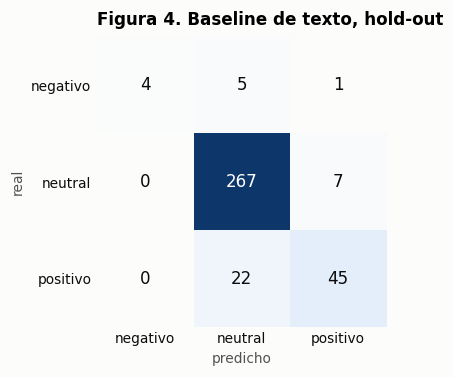

In [10]:
BASE = "B2 TF-IDF+RL, texto, pesos de clase"        # baseline oficial del grupo: solo texto
p_cv, p_ho, clf_base, entrada_base = pred[BASE]
print(classification_report(hold.Sentimiento, p_ho, labels=LABELS, digits=3, zero_division=0))

# Incertidumbre: bootstrap sobre el hold-out
rng = np.random.default_rng(SEED); y = hold.Sentimiento.values; A, F = [], []
for _ in range(2000):
    i = rng.integers(0, len(y), len(y))
    A.append(accuracy_score(y[i], p_ho[i])); F.append(f1_score(y[i], p_ho[i], average="macro", labels=LABELS, zero_division=0))
ic_acc, ic_f1 = np.percentile(A, [2.5, 97.5]), np.percentile(F, [2.5, 97.5])
print(f"IC 95 % (bootstrap, n={len(y)}): accuracy [{ic_acc[0]:.3f}, {ic_acc[1]:.3f}] | F1 macro [{ic_f1[0]:.3f}, {ic_f1[1]:.3f}]")

# Figura 4: matriz de confusión del baseline en el hold-out
cm = confusion_matrix(hold.Sentimiento, p_ho, labels=LABELS)
fig, ax = plt.subplots(figsize=(4.8, 3.5))
ax.imshow(cm, cmap=matplotlib.colors.LinearSegmentedColormap.from_list("azul", ["#fcfcfb", "#cde2fb", "#3987e5", "#0d366b"]))
for i in range(3):
    for j in range(3):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=11,
                color="white" if cm[i, j] > cm.max() * 0.5 else INK)
ax.set_xticks(range(3)); ax.set_xticklabels(LABELS, color=INK); ax.set_yticks(range(3)); ax.set_yticklabels(LABELS, color=INK)
ax.set_xlabel("predicho"); ax.set_ylabel("real"); ax.spines[:].set_visible(False); ax.tick_params(length=0)
ax.set_title("Figura 4. Baseline de texto, hold-out", pad=8)
plt.tight_layout(); plt.show()

In [11]:
# ¿Qué está aprendiendo un modelo de solo texto? Tres pruebas de diagnóstico.
p_sitio = cross_val_predict(modelo_clasico("balanced"), train.texto, train.Sitio, cv=FOLDS)
print(f"1) Adivinar la PLATAFORMA desde el texto: accuracy = {accuracy_score(train.Sitio, p_sitio):.3f}")

print("2) Dentro de cada plataforma (entrena y evalúa solo ahí):")
for s in ("Foursquare", "Tripadvisor"):
    a, b = train[train.Sitio == s], hold[hold.Sitio == s]
    q = modelo_clasico("balanced").fit(a.texto, a.Sentimiento).predict(b.texto)
    print(f"   {s:<12} accuracy {accuracy_score(b.Sentimiento, q):.3f} vs. mayoritaria {b.Sentimiento.value_counts(normalize=True).max():.3f} (n={len(b)})")

grupos = train["Nombre del lugar"] + "|" + train.Sitio
cv_lugar = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
q = cross_val_predict(modelo_clasico("balanced"), train.texto, train.Sentimiento, cv=cv_lugar, groups=grupos)
f = f1_score(train.Sentimiento, q, average=None, labels=LABELS, zero_division=0)
print(f"3) Validando con lugares NUNCA vistos: accuracy {accuracy_score(train.Sentimiento, q):.3f} | "
      f"F1 negativo {f[0]:.3f}, neutral {f[1]:.3f}, positivo {f[2]:.3f}")

1) Adivinar la PLATAFORMA desde el texto: accuracy = 0.943
2) Dentro de cada plataforma (entrena y evalúa solo ahí):
   Foursquare   accuracy 0.778 vs. mayoritaria 0.744 (n=90)
   Tripadvisor  accuracy 0.985 vs. mayoritaria 0.962 (n=261)
3) Validando con lugares NUNCA vistos: accuracy 0.833 | F1 negativo 0.000, neutral 0.904, positivo 0.571


**Lectura del baseline**

- El modelo de texto supera con claridad a la clase mayoritaria, pero casi toda la ganancia viene de distinguir
  la plataforma; dentro de cada plataforma apenas mejora a la mayoritaria.
- Con lugares no vistos, el F1 de `negativo` cae a 0: el modelo reconocía el lugar, no la queja.
- Añadir los metadatos del lugar al texto lleva el resultado casi a 100 %. Es una entrada válida en la competencia
  (esas columnas vienen en el archivo de envío), pero convierte la tarea en leer una calificación.
  **Decisión pendiente del grupo, a consultar con el docente:** solo texto (recomendado como modelo principal)
  o texto + metadatos (reportado aparte como experimento).
- `accuracy` premia predecir siempre `neutral` (0,78). Por eso se reporta **F1 macro** junto a la métrica oficial.

In [12]:
# Registro de experimentos (se sigue llenando en la Parte 2)
log = resultados.copy()
log.insert(0, "id", ["B0", "B1", "B2", "B3", "R"])
log["cambio"] = ["piso", "baseline", "B1 + pesos de clase", "B2 + metadatos del lugar", "regla (atajo, no es un modelo)"]
log["entrada"] = ["-", "texto", "texto", "texto+metadatos", "Valoración_num"]
log["split"] = f"{N_FOLDS}-fold estratificado + hold-out"; log["seed"] = SEED
log["fecha"] = time.strftime("%Y-%m-%d %H:%M")
log.round(4).to_csv(f"{OUT_DIR}/experimentos.csv", index=False)
print(log.round(4)[["id", "cambio", "entrada", "acc_cv", "f1_macro_cv", "acc_holdout", "f1_macro_holdout", "tiempo_s"]].to_string(index=False))

id                         cambio         entrada  acc_cv  f1_macro_cv  acc_holdout  f1_macro_holdout  tiempo_s
B0                           piso               -  0.7779       0.2917       0.7806            0.2923    0.0000
B1                       baseline           texto  0.8821       0.6275       0.8632            0.5184   10.1971
B2            B1 + pesos de clase           texto  0.9032       0.7137       0.9003            0.7539    9.0221
B3       B2 + metadatos del lugar texto+metadatos  0.9926       0.9854       0.9972            0.9969    9.2985
 R regla (atajo, no es un modelo)  Valoración_num  1.0000       1.0000       1.0000            1.0000    0.0000


In [13]:
# Archivo de envío del baseline. Formato comprobado en Kaggle: con etiquetas en texto el puntaje fue 0,00;
# con números (negativo=0, neutral=1, positivo=2) fue 0,87.
FORMATO = "numero"     # "numero": 0/1/2 (el que acepta Kaggle) | "texto": negativo/neutral/positivo
p_envio = clf_base.predict(entrada_base(sub))
envio = pd.DataFrame({"ID": sub.ID, "Sentimiento": p_envio})
if FORMATO == "numero":
    envio["Sentimiento"] = envio.Sentimiento.map(LABEL2ID)
assert len(envio) == len(sub) == 129 and envio.ID.is_unique and envio.Sentimiento.notna().all()
envio.to_csv(f"{OUT_DIR}/submission_baseline.csv", index=False)
print(envio.Sentimiento.value_counts().to_dict()); print(envio.head())

{1: 102, 2: 26, 0: 1}
     ID  Sentimiento
0   980            1
1  1249            1
2   260            1
3   459            1
4   309            2


**QA Fases 2–3**

| Riesgo | Método | Evidencia |
|---|---|---|
| Fuga por duplicados | Quitar de train los textos del hold-out y dejar un ejemplar por texto | Aserciones de la celda de partición |
| Folds desiguales o sin una clase | Estratificación exacta + aserción (4 o 5 negativos por fold) | Tabla fold × clase |
| Formato de envío ambiguo en la descripción | Envío de prueba con el baseline | 0,00 con texto; 0,87 con números |
| Varianza por pocos negativos | 5 folds + bootstrap en hold-out | Intervalo de confianza del baseline |
| Sobreajuste al leaderboard | El hold-out local (351) decide; el leaderboard público se calcula sobre una parte de 129 filas | Cada fila mueve más de 0,7 puntos de accuracy |
| Atajos | Pruebas 1–3 de diagnóstico | Plataforma predecible desde el texto; caída con lugares no vistos |

### Criterios de éxito (fijados antes de entrenar BART)

Propuesta del grupo; los umbrales se calculan a partir del baseline B2 en la celda siguiente y **no se cambian
después de ver los resultados de BART**. La Fase 4 termina con un Sí/No frente a estos números.

| Nivel | Criterio | Umbral |
|---|---|---|
| Negocio | Detectar reseñas negativas: recall de `negativo` en el hold-out | ≥ 0,50 (el baseline detecta 3 de 10) |
| ML | F1 macro en el hold-out | ≥ baseline B2 + 0,03 |
| ML | Métrica oficial (accuracy) en el hold-out | ≥ baseline B2 (no empeorar) |
| Económico | Entrenamiento de una corrida completa (5 folds) en una GPU T4 | ≤ 15 min |
| Económico | Inferencia por reseña y tamaño del modelo | Se miden en la Fase 5 |

Hipótesis de trabajo: como la etiqueta depende del lugar y de la plataforma, un Transformer que solo lee el texto
mejorará poco la accuracy del baseline (techo cercano a 0,90) y su ganancia, si existe, estará en `positivo` y `negativo`.

In [14]:
_b2 = resultados[resultados.modelo.str.startswith("B2")].iloc[0]
CRITERIOS = {"recall_negativo_min": 0.50,
             "f1_macro_holdout_min": round(float(_b2.f1_macro_holdout) + 0.03, 4),
             "acc_holdout_min": round(float(_b2.acc_holdout), 4),
             "minutos_por_corrida_max": 15}
print("Criterios de éxito:", CRITERIOS)

Criterios de éxito: {'recall_negativo_min': 0.5, 'f1_macro_holdout_min': 0.7839, 'acc_holdout_min': 0.9003, 'minutos_por_corrida_max': 15}


---
# Parte 2 — Fine-tuning de BART (Fase 3)

**Cómo ejecutar.** En *Settings → Accelerator* elegir **GPU T4 ×2**, con Internet activado, y lanzar con
*Save Version → Save & Run All (Commit)*. Así corre en segundo plano en los servidores de Kaggle y no depende de tener
el navegador abierto: la corrida completa toma unas 3 horas y una sesión interactiva puede cortarse por inactividad.

**Arquitectura.** BART es encoder-decoder. Para clasificar, el mismo texto entra al encoder y al decoder;
se toma el estado oculto del decoder en el último token (`</s>`) y pasa por una cabeza de clasificación
(capa densa + tanh + capa de salida de 3 clases), que se inicializa al azar. Por defecto se ajustan todos los pesos.
En el experimento E5 se congela el encoder (junto con los embeddings, que BART comparte con el decoder) y solo
se entrenan el decoder y la cabeza.

**Entrenamiento.** AdamW, learning rate con calentamiento lineal (10 % de los pasos) y decaimiento lineal,
entropía cruzada (con pesos de clase en E3), recorte de gradiente a 1,0 y parada temprana por F1 macro de validación.
Se usa una sola GPU para que el tamaño de lote sea el mismo en todas las corridas.

**Diseño experimental.** Cada experimento cambia **una sola cosa** respecto a su experimento base (columna `base`).
Cada corrida entrena en los mismos 5 folds del baseline; el hold-out se predice promediando las probabilidades de
los 5 modelos y no interviene en ninguna decisión.

In [15]:
# Utilidades sin PyTorch, con su prueba unitaria
def por_longitud(textos):
    # Índices de los textos del más corto al más largo: los lotes de predicción llevan menos relleno y van más rápido
    return sorted(range(len(textos)), key=lambda i: len(textos[i]))

def deshacer_orden(valores, orden):
    # Devuelve cada fila a la posición del texto original
    salida = np.empty_like(valores); salida[orden] = valores
    return salida

_t = ["ccc", "a", "bb", "dddd"]; _o = por_longitud(_t)
assert [_t[i] for i in _o] == ["a", "bb", "ccc", "dddd"]
assert deshacer_orden(np.array([[len(_t[i])] for i in _o]), _o).ravel().tolist() == [3, 1, 2, 4]
print("Prueba unitaria de ordenamiento: correcta")

Prueba unitaria de ordenamiento: correcta


In [16]:
import gc, torch, transformers
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")      # una sola GPU
HARDWARE = torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "CPU"
ID2LABEL = {i: l for l, i in LABEL2ID.items()}
torch.use_deterministic_algorithms(True, warn_only=True)
print("torch", torch.__version__, "| transformers", transformers.__version__, "| hardware:", HARDWARE)
if DEVICE.type != "cuda":
    print("[aviso] No hay GPU activa: el entrenamiento será muy lento. Activa GPU T4 en Settings → Accelerator.")

def fijar_semilla(s):
    random.seed(s); np.random.seed(s); torch.manual_seed(s); torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False

_TOK = {}
def tokenizador(ckpt):
    if ckpt not in _TOK:
        _TOK[ckpt] = AutoTokenizer.from_pretrained(ckpt)
    return _TOK[ckpt]

def codificar(tok, textos, max_length):
    # Truncamiento al final: se conserva el inicio de la reseña y el token </s> de cierre
    enc = tok(textos, truncation=True, max_length=max_length, padding=True, return_tensors="pt")
    return enc["input_ids"].to(DEVICE), enc["attention_mask"].to(DEVICE)

@torch.no_grad()
def predecir(model, tok, textos, max_length, lote=64):
    # Devuelve probabilidades (n, 3)
    model.eval(); salida = []
    orden = por_longitud(textos)
    for i in range(0, len(orden), lote):
        ids, att = codificar(tok, [textos[j] for j in orden[i:i + lote]], max_length)
        logits = model(input_ids=ids, attention_mask=att).logits
        salida.append(torch.softmax(logits.float(), dim=-1).cpu().numpy())
    return deshacer_orden(np.concatenate(salida), orden)

def crear_modelo(cfg):
    model = AutoModelForSequenceClassification.from_pretrained(
        cfg["ckpt"], num_labels=len(LABELS), id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True)
    if cfg["congelar_encoder"]:
        for p in model.model.encoder.parameters():      # incluye los embeddings compartidos con el decoder
            p.requires_grad = False
    return model.to(DEVICE)

def entrenar(cfg, tr_txt, tr_y, va_txt=None, va_y=None, extra=None, seed=42, epocas=None, conservar=False):
    # Con validación: parada temprana por F1 macro y predicciones de la mejor época.
    # Sin validación (modelo final): número fijo de épocas.
    fijar_semilla(seed)
    tok, model = tokenizador(cfg["ckpt"]), crear_modelo(cfg)
    assert model.config.eos_token_id == tok.eos_token_id, "el </s> del tokenizer no coincide con el del modelo"
    entrenables = [p for p in model.parameters() if p.requires_grad]
    info = {"params_entrenables": sum(p.numel() for p in entrenables),
            "params_totales": sum(p.numel() for p in model.parameters())}
    opt = torch.optim.AdamW(entrenables, lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    tr_y = np.asarray(tr_y)
    dl = DataLoader(list(range(len(tr_txt))), batch_size=cfg["batch"], shuffle=True,
                    generator=torch.Generator().manual_seed(seed))
    n_epocas = epocas or cfg["epocas"]
    pasos = len(dl) * n_epocas
    sched = get_linear_schedule_with_warmup(opt, int(cfg["warmup"] * pasos), pasos)
    pesos = None
    if cfg["pesos_clase"]:
        conteo = np.bincount(tr_y, minlength=len(LABELS))
        pesos = torch.tensor(len(tr_y) / (len(LABELS) * np.maximum(conteo, 1)), dtype=torch.float, device=DEVICE)
    perdida = torch.nn.CrossEntropyLoss(weight=pesos)

    extra = extra or {}
    mejor = {"f1": -1.0, "epoca": 0, "p_va": None, "extra": {}}
    hist, espera = [], 0
    for ep in range(1, n_epocas + 1):
        model.train(); suma, n = 0.0, 0
        for lote in dl:
            lote = [int(i) for i in lote]
            ids, att = codificar(tok, [tr_txt[i] for i in lote], cfg["max_length"])
            y = torch.as_tensor(tr_y[lote], dtype=torch.long, device=DEVICE)
            loss = perdida(model(input_ids=ids, attention_mask=att).logits.float(), y)
            opt.zero_grad(set_to_none=True)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(entrenables, 1.0)
            opt.step(); sched.step()
            suma += loss.item() * len(lote); n += len(lote)
        fila = {"epoca": ep, "train_loss": suma / n}
        assert np.isfinite(fila["train_loss"]), "la pérdida de entrenamiento no es finita"
        if va_txt is not None:
            va_y = np.asarray(va_y)
            p_va = predecir(model, tok, va_txt, cfg["max_length"])
            fila["val_loss"] = float(-np.log(np.clip(p_va[np.arange(len(va_y)), va_y], 1e-9, 1)).mean())
            fila["val_f1_macro"] = f1_score(va_y, p_va.argmax(1), average="macro", labels=[0, 1, 2], zero_division=0)
            fila["val_acc"] = accuracy_score(va_y, p_va.argmax(1))
            if fila["val_f1_macro"] > mejor["f1"] + 1e-9:
                mejor = {"f1": fila["val_f1_macro"], "epoca": ep, "p_va": p_va,
                         "extra": {k: predecir(model, tok, v, cfg["max_length"]) for k, v in extra.items()}}
                espera = 0
            else:
                espera += 1
        hist.append(fila)
        if va_txt is not None and espera >= cfg["paciencia"]:
            break
    if va_txt is None:
        mejor = {"f1": float("nan"), "epoca": n_epocas, "p_va": None,
                 "extra": {k: predecir(model, tok, v, cfg["max_length"]) for k, v in extra.items()}}
    mejor.update(hist=hist, info=info, modelo=model if conservar else None)
    if not conservar:
        del model
    del opt, sched
    gc.collect()
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return mejor

torch 2.11.0+cu128 | transformers 5.16.1 | hardware: Tesla T4


In [17]:
CFG_BASE = dict(ckpt=CKPT, entrada="texto", max_length=MAX_LENGTH, lr=3e-5, batch=16, epocas=8, paciencia=2,
                warmup=0.1, weight_decay=0.01, pesos_clase=False, congelar_encoder=False, seed=SEED)

Y = train.Sentimiento.map(LABEL2ID).values
Y_HO = hold.Sentimiento.map(LABEL2ID).values

def entrada(d, modo):
    return (con_metadatos(d) if modo == "texto+metadatos" else d.texto).tolist()

def metricas_id(y, p):
    return {"acc": accuracy_score(y, p), "f1_macro": f1_score(y, p, average="macro", labels=[0, 1, 2], zero_division=0)}

RES = {}     # resultados por experimento: configuración, predicciones, curvas y fila del registro

# Cada experimento terminado se guarda en disco. Si la sesión se corta y los archivos siguen ahí,
# al volver a ejecutar se recupera en vez de entrenar otra vez (solo si la configuración y los folds son idénticos).
import pickle, hashlib
CACHE_DIR = f"{OUT_DIR}/experimentos"; os.makedirs(CACHE_DIR, exist_ok=True)
FIRMA = hashlib.md5(train[["ID", "fold"]].to_csv(index=False).encode()).hexdigest()

def guardar_registro():
    todo_log = pd.concat([log, pd.DataFrame([r["fila"] for r in RES.values()])], ignore_index=True)
    todo_log.round(4).to_csv(f"{OUT_DIR}/experimentos.csv", index=False)
    return todo_log

def correr(id_, cambio, base=None, **cambios):
    cfg = dict(RES[base]["cfg"]) if base else dict(CFG_BASE)
    cfg.update(cambios)
    ruta = f"{CACHE_DIR}/{id_}.pkl"
    if os.path.exists(ruta):
        previo = pickle.load(open(ruta, "rb"))
        if previo["cfg"] == cfg and previo.get("firma") == FIRMA:
            RES[id_] = previo; guardar_registro()
            print(f"{id_} [{cambio}] recuperado de disco: F1 macro CV {previo['fila']['f1_macro_cv']:.4f}")
            return
    X, X_ho, X_sub = entrada(train, cfg["entrada"]), entrada(hold, cfg["entrada"]), entrada(sub, cfg["entrada"])
    oof = np.zeros((len(train), 3)); p_ho = np.zeros((len(hold), 3)); p_sub = np.zeros((len(sub), 3))
    hist, epocas, f1_fold, info = [], [], [], {}
    t0 = time.time()
    for k, (tr, va) in enumerate(FOLDS):
        r = entrenar(cfg, [X[i] for i in tr], Y[tr], [X[i] for i in va], Y[va],
                     extra={"hold": X_ho, "envio": X_sub}, seed=cfg["seed"])
        oof[va] = r["p_va"]; p_ho += r["extra"]["hold"] / N_FOLDS; p_sub += r["extra"]["envio"] / N_FOLDS
        hist += [dict(h, fold=k) for h in r["hist"]]
        epocas.append(r["epoca"]); f1_fold.append(r["f1"]); info = r["info"]
        print(f"  {id_} fold {k}: mejor época {r['epoca']} | F1 macro val {r['f1']:.3f}")
    m, h = metricas_id(Y, oof.argmax(1)), metricas_id(Y_HO, p_ho.argmax(1))
    f = f1_score(Y, oof.argmax(1), average=None, labels=[0, 1, 2], zero_division=0)
    fila = {"id": id_, "modelo": cfg["ckpt"], "cambio": cambio, "base": base or "-", "entrada": cfg["entrada"],
            "lr": cfg["lr"], "max_length": cfg["max_length"], "pesos_clase": cfg["pesos_clase"],
            "congelar_encoder": cfg["congelar_encoder"], "seed": cfg["seed"],
            "acc_cv": m["acc"], "f1_macro_cv": m["f1_macro"], "f1_macro_cv_std": float(np.std(f1_fold)),
            "f1_neg_cv": f[0], "f1_neu_cv": f[1], "f1_pos_cv": f[2],
            "acc_holdout": h["acc"], "f1_macro_holdout": h["f1_macro"],
            "epoca_media": float(np.mean(epocas)), "params_entrenables": info.get("params_entrenables"),
            "tiempo_s": time.time() - t0, "hardware": HARDWARE,
            "split": f"{N_FOLDS}-fold estratificado + hold-out", "fecha": time.strftime("%Y-%m-%d %H:%M")}
    RES[id_] = {"cfg": cfg, "oof": oof, "p_ho": p_ho, "p_sub": p_sub, "hist": pd.DataFrame(hist),
                "f1_fold": f1_fold, "fila": fila, "firma": FIRMA}
    pickle.dump(RES[id_], open(ruta, "wb"))
    guardar_registro()
    print(f"{id_} [{cambio}] CV: acc {m['acc']:.4f}, F1 macro {m['f1_macro']:.4f} ± {np.std(f1_fold):.3f} | "
          f"hold-out: acc {h['acc']:.4f}, F1 macro {h['f1_macro']:.4f} | {fila['tiempo_s'] / 60:.1f} min")

### Prueba de humo del pipeline (QA)

Antes de gastar GPU en los experimentos se recorre, con pocos ejemplos **de train** y una sola época, cada camino
que se usará después: los dos checkpoints, el encoder congelado, los pesos de clase, la entrada con metadatos y el
modelo final (entrenar sin validación, guardar, volver a cargar y predecir). Se comprueba que cada texto tokenizado
tiene exactamente un `</s>` (BART clasifica con ese token), que ninguno supera `max_length`, que las probabilidades
suman 1, que la pérdida es finita y que el modelo recargado desde disco predice lo mismo que el que se guardó.
Si algo falla, falla aquí en un par de minutos y no después de horas de entrenamiento.

In [18]:
# PRUEBA DE HUMO
import shutil
t0 = time.time()
mini_tr = train[train.fold != 0].groupby("Sentimiento").head(16)
mini_va = train[train.fold == 0].head(48)
y_tr, y_va = mini_tr.Sentimiento.map(LABEL2ID).values, mini_va.Sentimiento.map(LABEL2ID).values
casos = [("BARTO, configuración base", dict(CFG_BASE, epocas=1)),
         ("BARTO, encoder congelado + pesos de clase", dict(CFG_BASE, epocas=1, congelar_encoder=True, pesos_clase=True)),
         ("facebook/bart-base", dict(CFG_BASE, epocas=1, ckpt="facebook/bart-base")),
         ("BARTO, texto + metadatos", dict(CFG_BASE, epocas=1, entrada="texto+metadatos"))]
for nombre, cfg in casos:
    t1 = time.time()
    tok = tokenizador(cfg["ckpt"])
    ids = tok(entrada(train.head(300), cfg["entrada"]), truncation=True, max_length=cfg["max_length"])["input_ids"]
    assert all(x.count(tok.eos_token_id) == 1 for x in ids), f"{nombre}: algún texto no tiene exactamente un </s>"
    assert max(len(x) for x in ids) <= cfg["max_length"], f"{nombre}: hay textos más largos que max_length"
    r = entrenar(cfg, entrada(mini_tr, cfg["entrada"]), y_tr, entrada(mini_va, cfg["entrada"]), y_va,
                 extra={"envio": entrada(sub.head(8), cfg["entrada"])}, seed=SEED)
    assert r["p_va"].shape == (len(mini_va), 3) and np.allclose(r["p_va"].sum(1), 1, atol=1e-4), nombre
    assert r["extra"]["envio"].shape == (8, 3), nombre
    if cfg["congelar_encoder"]:
        assert r["info"]["params_entrenables"] < r["info"]["params_totales"], "el encoder no quedó congelado"
    print(f"  correcto: {nombre} | {time.time() - t1:.0f} s | pérdida {r['hist'][0]['train_loss']:.3f} | "
          f"parámetros {r['info']['params_totales'] / 1e6:.1f} M (entrenables {r['info']['params_entrenables'] / 1e6:.1f} M)")

# Camino del modelo final: entrenar sin validación, guardar, recargar desde disco y predecir
t1 = time.time()
r = entrenar(dict(CFG_BASE), mini_tr.texto.tolist(), y_tr, extra={"envio": sub.texto.head(8).tolist()},
             seed=SEED, epocas=1, conservar=True)
dir_prueba = f"{OUT_DIR}/_prueba_modelo"
r["modelo"].save_pretrained(dir_prueba); tokenizador(CKPT).save_pretrained(dir_prueba)
r["modelo"] = None; gc.collect()
recargado = AutoModelForSequenceClassification.from_pretrained(dir_prueba).to(DEVICE)
p_recargado = predecir(recargado, AutoTokenizer.from_pretrained(dir_prueba), sub.texto.head(8).tolist(), MAX_LENGTH)
assert np.allclose(p_recargado, r["extra"]["envio"], atol=1e-3), "el modelo recargado no predice igual que el guardado"
del recargado; gc.collect(); shutil.rmtree(dir_prueba)
if DEVICE.type == "cuda":
    torch.cuda.empty_cache()
print(f"  correcto: guardar, recargar y predecir | {time.time() - t1:.0f} s")
print(f"Prueba de humo correcta en {time.time() - t0:.0f} s")

model.safetensors: reconstructing file:   0%|          |  0.00B /  558MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  correcto: BARTO, configuración base | 13 s | pérdida 1.100 | parámetros 140.0 M (entrenables 140.0 M)


...

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/263 [00:00<?, ?it/s]

  correcto: guardar, recargar y predecir | 5 s
Prueba de humo correcta en 35 s


### Experimentos

| ID | Cambio (uno solo) | Base | Pregunta que responde |
|---|---|---|---|
| E1 | BARTO, configuración base | – | Punto de partida |
| E2 | Learning rate 3e-5 → 5e-5 | E1 | Sensibilidad al hiperparámetro principal |
| E3 | Pesos de clase en la pérdida | E1 | ¿Mejora la clase `negativo`? |
| E4 | `max_length` 384 → 128 | E1 | ¿Cuánto cuesta truncar más reseñas? |
| E5 | Encoder congelado | E1 | ¿Qué pasa si se congela el encoder? |
| E6 | Checkpoint `facebook/bart-base` (inglés) | E1 | Español frente a inglés, mismo tamaño |
| E7a, E7b | Otras dos semillas | la mejor | Variación por azar |
| E8 | Entrada texto + metadatos del lugar | la mejor | Cuánto aporta el atajo (se reporta aparte) |

In [19]:
correr("E1", "BARTO, configuración base")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E1 fold 0: mejor época 3 | F1 macro val 0.603


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E1 fold 3: mejor época 5 | F1 macro val 0.565


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E1 fold 4: mejor época 4 | F1 macro val 0.599
E1 [BARTO, configuración base] CV: acc 0.8933, F1 macro 0.6059 ± 0.041 | hold-out: acc 0.8746, F1 macro 0.5591 | 20.1 min


In [20]:
correr("E2", "learning rate 3e-5 -> 5e-5", base="E1", lr=5e-5)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E2 fold 0: mejor época 3 | F1 macro val 0.595


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E2 fold 3: mejor época 3 | F1 macro val 0.577


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E2 fold 4: mejor época 1 | F1 macro val 0.593
E2 [learning rate 3e-5 -> 5e-5] CV: acc 0.8871, F1 macro 0.5735 ± 0.021 | hold-out: acc 0.8860, F1 macro 0.5746 | 14.1 min


In [21]:
correr("E3", "pesos de clase en la pérdida", base="E1", pesos_clase=True)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E3 fold 0: mejor época 3 | F1 macro val 0.579


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E3 fold 3: mejor época 5 | F1 macro val 0.580


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E3 fold 4: mejor época 7 | F1 macro val 0.812
E3 [pesos de clase en la pérdida] CV: acc 0.8859, F1 macro 0.6729 ± 0.099 | hold-out: acc 0.8860, F1 macro 0.6325 | 21.1 min


In [22]:
correr("E4", f"max_length {MAX_LENGTH} -> 128", base="E1", max_length=128)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E4 fold 0: mejor época 6 | F1 macro val 0.598


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E4 fold 3: mejor época 2 | F1 macro val 0.565


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E4 fold 4: mejor época 4 | F1 macro val 0.599
E4 [max_length 384 -> 128] CV: acc 0.8908, F1 macro 0.5771 ± 0.017 | hold-out: acc 0.8889, F1 macro 0.5762 | 10.4 min


In [23]:
correr("E5", "encoder congelado", base="E1", congelar_encoder=True)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E5 fold 0: mejor época 1 | F1 macro val 0.563


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E5 fold 3: mejor época 3 | F1 macro val 0.574


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E5 fold 4: mejor época 4 | F1 macro val 0.593
E5 [encoder congelado] CV: acc 0.8821, F1 macro 0.5696 ± 0.013 | hold-out: acc 0.8803, F1 macro 0.5680 | 14.9 min


In [24]:
correr("E6", "checkpoint facebook/bart-base (inglés)", base="E1", ckpt="facebook/bart-base")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.out_proj.weight | MISSING | 
classification_head.dense.weight    | MISSING | 
classification_head.dense.bias      | MISSING | 
classification_head.out_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E6 fold 0: mejor época 5 | F1 macro val 0.596


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.out_proj.weight | MISSING | 
classification_head.dense.weight    | MISSING | 
classification_head.dense.bias      | MISSING | 
classification_head.out_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.out_proj.weight | MISSING | 
classification_head.dense.weight    | MISSING | 
classification_head.dense.bias      | MISSING | 
classification_head.out_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E6 fold 3: mejor época 3 | F1 macro val 0.592


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: facebook/bart-base
Key                                 | Status  | 
------------------------------------+---------+-
classification_head.out_proj.weight | MISSING | 
classification_head.dense.weight    | MISSING | 
classification_head.dense.bias      | MISSING | 
classification_head.out_proj.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E6 fold 4: mejor época 8 | F1 macro val 0.650
E6 [checkpoint facebook/bart-base (inglés)] CV: acc 0.9007, F1 macro 0.6112 ± 0.025 | hold-out: acc 0.8946, F1 macro 0.5769 | 25.0 min


### Selección de la configuración

Regla fijada de antemano: gana el experimento de **solo texto** con mayor F1 macro en validación cruzada.
El hold-out y el leaderboard no participan en la elección.

In [25]:
candidatos = [i for i in ("E1", "E2", "E3", "E4", "E5", "E6") if i in RES]
MEJOR = max(candidatos, key=lambda i: RES[i]["fila"]["f1_macro_cv"])
print("Configuración elegida:", MEJOR, "->", RES[MEJOR]["fila"]["cambio"])

Configuración elegida: E3 -> pesos de clase en la pérdida


In [26]:
correr("E7a", "semilla 42 -> 43", base=MEJOR, seed=SEED + 1)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E7a fold 0: mejor época 7 | F1 macro val 0.603


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E7a fold 3: mejor época 3 | F1 macro val 0.572


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E7a fold 4: mejor época 7 | F1 macro val 0.683
E7a [semilla 42 -> 43] CV: acc 0.8821, F1 macro 0.6173 ± 0.045 | hold-out: acc 0.8775, F1 macro 0.5673 | 24.6 min


In [27]:
correr("E7b", "semilla 42 -> 44", base=MEJOR, seed=SEED + 2)

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E7b fold 0: mejor época 4 | F1 macro val 0.591


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E7b fold 3: mejor época 5 | F1 macro val 0.591


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E7b fold 4: mejor época 6 | F1 macro val 0.824
E7b [semilla 42 -> 44] CV: acc 0.8685, F1 macro 0.6324 ± 0.103 | hold-out: acc 0.8775, F1 macro 0.5682 | 20.9 min


In [28]:
semillas = [RES[i]["fila"] for i in (MEJOR, "E7a", "E7b")]
for col in ("acc_cv", "f1_macro_cv", "acc_holdout", "f1_macro_holdout"):
    v = [s[col] for s in semillas]
    print(f"{col:<18} media {np.mean(v):.4f} | desviación entre 3 semillas {np.std(v):.4f} | valores {np.round(v, 4)}")

acc_cv             media 0.8788 | desviación entre 3 semillas 0.0075 | valores [0.8859 0.8821 0.8685]
f1_macro_cv        media 0.6409 | desviación entre 3 semillas 0.0235 | valores [0.6729 0.6173 0.6324]
acc_holdout        media 0.8803 | desviación entre 3 semillas 0.0040 | valores [0.886  0.8775 0.8775]
f1_macro_holdout   media 0.5893 | desviación entre 3 semillas 0.0305 | valores [0.6325 0.5673 0.5682]


In [29]:
correr("E8", "entrada texto -> texto + metadatos del lugar", base=MEJOR, entrada="texto+metadatos")

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E8 fold 0: mejor época 4 | F1 macro val 1.000


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


...

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E8 fold 3: mejor época 4 | F1 macro val 1.000


Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  E8 fold 4: mejor época 3 | F1 macro val 1.000
E8 [entrada texto -> texto + metadatos del lugar] CV: acc 1.0000, F1 macro 1.0000 ± 0.000 | hold-out: acc 1.0000, F1 macro 1.0000 | 21.3 min


In [30]:
tabla = guardar_registro()
cols = ["id", "cambio", "base", "acc_cv", "f1_macro_cv", "f1_macro_cv_std", "f1_neg_cv", "acc_holdout",
        "f1_macro_holdout", "epoca_media", "tiempo_s"]
print(tabla[cols].round(3).to_string(index=False))

 id                                       cambio base  acc_cv  f1_macro_cv  f1_macro_cv_std  f1_neg_cv  acc_holdout  f1_macro_holdout  epoca_media  tiempo_s
 B0                                         piso  NaN   0.778        0.292              NaN        NaN        0.781             0.292          NaN     0.000
 B1                                     baseline  NaN   0.882        0.627              NaN        NaN        0.863             0.518          NaN    10.197
 B2                          B1 + pesos de clase  NaN   0.903        0.714              NaN        NaN        0.900             0.754          NaN     9.022
 B3                     B2 + metadatos del lugar  NaN   0.993        0.985              NaN        NaN        0.997             0.997          NaN     9.299
  R               regla (atajo, no es un modelo)  NaN   1.000        1.000              NaN        NaN        1.000             1.000          NaN     0.000
 E1                    BARTO, configuración base    -   0.

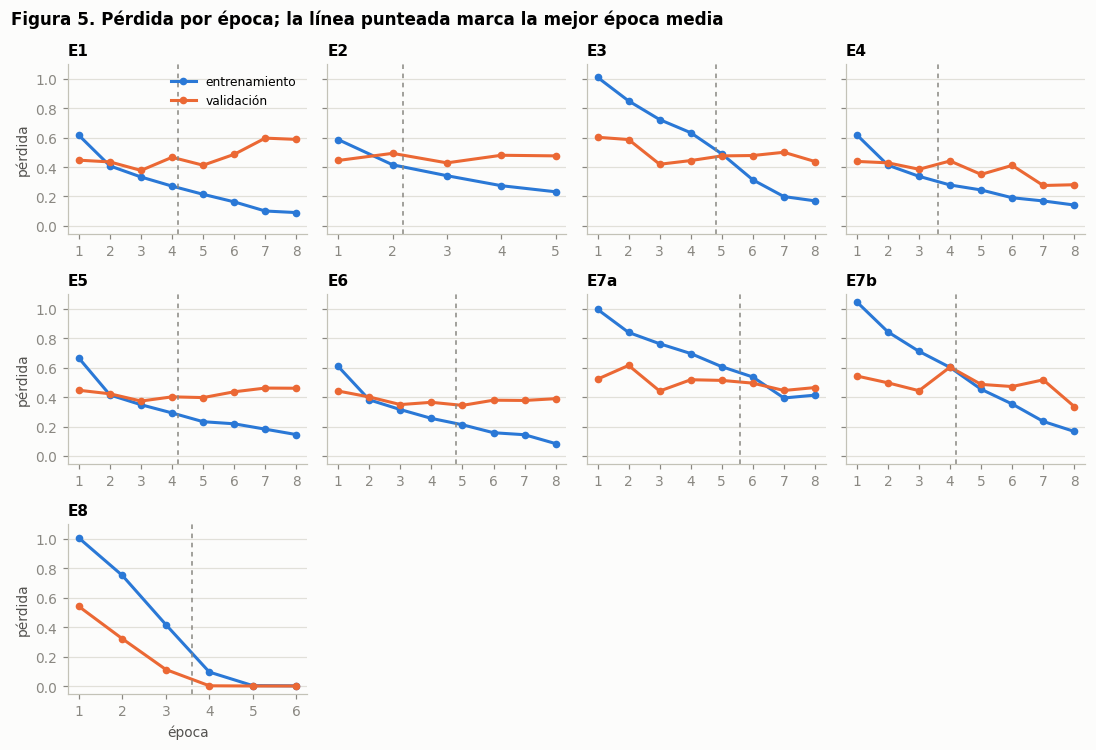

E1   última época: entrenamiento 0.091 | validación 0.588 | mínimo de validación en la época 3
E2   última época: entrenamiento 0.232 | validación 0.476 | mínimo de validación en la época 3
E3   última época: entrenamiento 0.170 | validación 0.438 | mínimo de validación en la época 3
E4   última época: entrenamiento 0.142 | validación 0.280 | mínimo de validación en la época 7
E5   última época: entrenamiento 0.145 | validación 0.460 | mínimo de validación en la época 3
E6   última época: entrenamiento 0.084 | validación 0.389 | mínimo de validación en la época 5
E7a  última época: entrenamiento 0.413 | validación 0.465 | mínimo de validación en la época 3
E7b  última época: entrenamiento 0.167 | validación 0.336 | mínimo de validación en la época 8
E8   última época: entrenamiento 0.001 | validación 0.000 | mínimo de validación en la época 6


In [31]:
# Figura 5: curvas de entrenamiento y validación (promedio de los 5 folds por época)
ids_exp = list(RES)
ncol = 4; nfil = int(np.ceil(len(ids_exp) / ncol))
fig, axs = plt.subplots(nfil, ncol, figsize=(10, 2.3 * nfil), sharey=True, squeeze=False)
for ax, i in zip(axs.ravel(), ids_exp):
    h = RES[i]["hist"].groupby("epoca")[["train_loss", "val_loss"]].mean()
    ax.plot(h.index, h.train_loss, color="#2a78d6", lw=2, marker="o", ms=4, label="entrenamiento")
    ax.plot(h.index, h.val_loss, color="#eb6834", lw=2, marker="o", ms=4, label="validación")
    ax.axvline(RES[i]["fila"]["epoca_media"], color=MUTED, lw=1, ls=(0, (3, 3)))
    ax.set_title(i, fontsize=10); ax.yaxis.grid(True, color=GRID); ax.set_axisbelow(True)
    ax.xaxis.set_major_locator(matplotlib.ticker.MaxNLocator(integer=True))
for ax in axs.ravel()[len(ids_exp):]:
    ax.axis("off")
for ax in axs[-1]:
    ax.set_xlabel("época")
for ax in axs[:, 0]:
    ax.set_ylabel("pérdida")
axs[0, 0].legend(fontsize=8, loc="upper right")
fig.suptitle("Figura 5. Pérdida por época; la línea punteada marca la mejor época media", x=0.01, ha="left",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

# Diagnóstico de sobreajuste: brecha entre validación y entrenamiento en la última época
for i in ids_exp:
    h = RES[i]["hist"].groupby("epoca")[["train_loss", "val_loss"]].mean()
    print(f"{i:<4} última época: entrenamiento {h.train_loss.iloc[-1]:.3f} | validación {h.val_loss.iloc[-1]:.3f} | "
          f"mínimo de validación en la época {int(h.val_loss.idxmin())}")

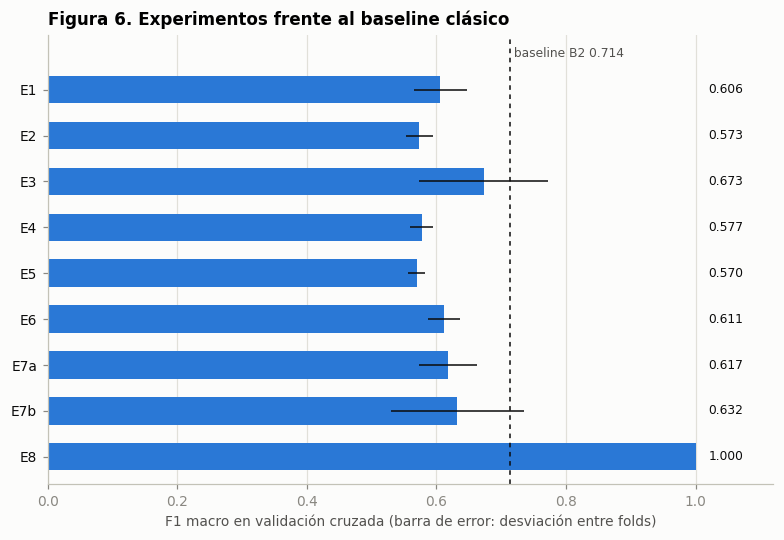

In [32]:
# Figura 6: F1 macro en validación cruzada por experimento, frente al baseline
orden = ids_exp[::-1]
val = [RES[i]["fila"]["f1_macro_cv"] for i in orden]; err = [RES[i]["fila"]["f1_macro_cv_std"] for i in orden]
base_cv = float(_b2.f1_macro_cv)
fig, ax = plt.subplots(figsize=(7.2, 0.42 * len(orden) + 1.2))
ax.barh(range(len(orden)), val, xerr=err, color="#2a78d6", height=0.6, error_kw={"ecolor": INK, "elinewidth": 1})
for j, v in enumerate(val):
    ax.text(1.02, j, f"{v:.3f}", va="center", fontsize=8, color=INK)      # columna fija: no choca con las barras
ax.axvline(base_cv, color=INK, lw=1, ls=(0, (3, 3)))
ax.text(base_cv, len(orden) - 0.35, f" baseline B2 {base_cv:.3f}", fontsize=8, color="#52514e", va="bottom")
ax.set_yticks(range(len(orden))); ax.set_yticklabels(orden, color=INK)
ax.set_ylim(-0.6, len(orden) + 0.2); ax.set_xlim(0, 1.12)
ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_xlabel("F1 macro en validación cruzada (barra de error: desviación entre folds)")
ax.xaxis.grid(True, color=GRID); ax.set_axisbelow(True)
ax.set_title("Figura 6. Experimentos frente al baseline clásico")
plt.tight_layout(); plt.show()

### Modelo final

Se reentrena la configuración elegida con **todo** el conjunto de entrenamiento, durante el número de épocas que
resultó mejor en promedio en la validación cruzada (sin mirar el hold-out), y se guarda. El hold-out se evalúa una vez.

In [33]:
cfg_final = dict(RES[MEJOR]["cfg"])
EPOCAS_FINAL = max(1, int(round(RES[MEJOR]["fila"]["epoca_media"])))
t0 = time.time()
final = entrenar(cfg_final, entrada(train, cfg_final["entrada"]), Y,
                 extra={"hold": entrada(hold, cfg_final["entrada"]), "envio": entrada(sub, cfg_final["entrada"])},
                 seed=cfg_final["seed"], epocas=EPOCAS_FINAL, conservar=True)
t_final = time.time() - t0

MODELO_DIR = f"{OUT_DIR}/modelo_final"
final["modelo"].save_pretrained(MODELO_DIR); tokenizador(cfg_final["ckpt"]).save_pretrained(MODELO_DIR)
json.dump({"cfg": cfg_final, "epocas": EPOCAS_FINAL, "labels": LABELS, "experimento_base": MEJOR},
          open(f"{MODELO_DIR}/entrenamiento.json", "w"), ensure_ascii=False, indent=1)
final["modelo"] = None; gc.collect()

P_HO_FINAL = final["extra"]["hold"]; pred_ho = P_HO_FINAL.argmax(1)
np.save(f"{OUT_DIR}/proba_holdout_final.npy", P_HO_FINAL); np.save(f"{OUT_DIR}/proba_oof_{MEJOR}.npy", RES[MEJOR]["oof"])
h = metricas_id(Y_HO, pred_ho)
print(f"Modelo final ({MEJOR}, {EPOCAS_FINAL} épocas, {t_final / 60:.1f} min) guardado en {MODELO_DIR}")
print(classification_report(Y_HO, pred_ho, labels=[0, 1, 2], target_names=LABELS, digits=3, zero_division=0))

RES["F"] = {"cfg": cfg_final, "p_ho": P_HO_FINAL, "hist": pd.DataFrame(final["hist"]), "f1_fold": [],
            "fila": {"id": "F", "modelo": cfg_final["ckpt"], "cambio": f"modelo final: {MEJOR} con todo train",
                     "base": MEJOR, "entrada": cfg_final["entrada"], "lr": cfg_final["lr"],
                     "max_length": cfg_final["max_length"], "pesos_clase": cfg_final["pesos_clase"],
                     "congelar_encoder": cfg_final["congelar_encoder"], "seed": cfg_final["seed"],
                     "acc_holdout": h["acc"], "f1_macro_holdout": h["f1_macro"], "epoca_media": EPOCAS_FINAL,
                     "params_entrenables": final["info"]["params_entrenables"], "tiempo_s": t_final,
                     "hardware": HARDWARE, "split": "todo train + hold-out", "fecha": time.strftime("%Y-%m-%d %H:%M")}}
guardar_registro()

Loading weights:   0%|          | 0/259 [00:00<?, ?it/s]

[transformers] BartForSequenceClassification LOAD REPORT from: vgaraujov/bart-base-spanish
Key                                 | Status     | 
------------------------------------+------------+-
final_logits_bias                   | UNEXPECTED | 
classification_head.out_proj.weight | MISSING    | 
classification_head.dense.weight    | MISSING    | 
classification_head.dense.bias      | MISSING    | 
classification_head.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Modelo final (E3, 5 épocas, 3.9 min) guardado en /kaggle/working/modelo_final
              precision    recall  f1-score   support

    negativo      0.200     0.100     0.133        10
     neutral      0.938     0.883     0.910       274
    positivo      0.682     0.896     0.774        67

    accuracy                          0.863       351
   macro avg      0.607     0.626     0.606       351
weighted avg      0.868     0.863     0.862       351



,id,modelo,acc_cv,f1_macro_cv,acc_holdout,f1_macro_holdout,tiempo_s,cambio,entrada,split,...,max_length,pesos_clase,congelar_encoder,f1_macro_cv_std,f1_neg_cv,f1_neu_cv,f1_pos_cv,epoca_media,params_entrenables,hardware
0,B0,B0 clase mayoritaria,0.777916,0.291696,0.780627,0.292267,0.000000,piso,-,5-fold estratificado + hold-out,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,B1,"B1 TF-IDF+RL, texto",0.882134,0.627478,0.863248,0.518391,10.197052,baseline,texto,5-fold estratificado + hold-out,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,B2,"B2 TF-IDF+RL, texto, pesos de clase",0.903226,0.713743,0.900285,0.753856,9.022064,B1 + pesos de clase,texto,5-fold estratificado + hold-out,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,B3,"B3 TF-IDF+RL, texto+metadatos, pesos",0.992556,0.985423,0.997151,0.996921,9.298522,B2 + metadatos del lugar,texto+metadatos,5-fold estratificado + hold-out,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,R,R regla sobre Valoración_num (atajo),1.000000,1.000000,1.000000,1.000000,0.000000,"regla (atajo, no es un modelo)",Valoración_num,5-fold estratificado + hold-out,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,E1,vgaraujov/bart-base-spanish,0.893300,0.605921,0.874644,0.559144,1205.534253,"BARTO, configuración base",texto,5-fold estratificado + hold-out,...,384.0,False,False,0.040989,0.083333,0.931962,0.802469,4.2,140012547.0,Tesla T4
6,E2,vgaraujov/bart-base-spanish,0.887097,0.573466,0.886040,0.574589,845.044132,learning rate 3e-5 -> 5e-5,texto,5-fold estratificado + hold-out,...,384.0,False,False,0.020609,0.000000,0.927605,0.792793,2.2,140012547.0,Tesla T4
7,E3,vgaraujov/bart-base-spanish,0.885856,0.672914,0.886040,0.632468,1266.357884,pesos de clase en la pérdida,texto,5-fold estratificado + hold-out,...,384.0,True,False,0.099420,0.303030,0.927653,0.788060,4.8,140012547.0,Tesla T4
8,E4,vgaraujov/bart-base-spanish,0.890819,0.577084,0.888889,0.576234,625.295134,max_length 384 -> 128,texto,5-fold estratificado + hold-out,...,128.0,False,False,0.017357,0.000000,0.930048,0.801205,3.6,140012547.0,Tesla T4
9,E5,vgaraujov/bart-base-spanish,0.882134,0.569574,0.880342,0.567966,895.961946,encoder congelado,texto,5-fold estratificado + hold-out,...,384.0,False,True,0.013054,0.000000,0.924061,0.784661,4.2,58093059.0,Tesla T4


In [34]:
# Comparación con el baseline y revisión preliminar de los criterios de éxito (la decisión formal va en la Fase 4)
rec_neg = float(((pred_ho == 0) & (Y_HO == 0)).sum() / max((Y_HO == 0).sum(), 1))
min_corrida = RES[MEJOR]["fila"]["tiempo_s"] / 60
print(f"Baseline B2  -> accuracy {_b2.acc_holdout:.4f} | F1 macro {_b2.f1_macro_holdout:.4f}")
print(f"BART final   -> accuracy {h['acc']:.4f} | F1 macro {h['f1_macro']:.4f} | recall negativo {rec_neg:.2f}\n")
revision = [("Recall de negativo", rec_neg, ">=", CRITERIOS["recall_negativo_min"]),
            ("F1 macro en hold-out", h["f1_macro"], ">=", CRITERIOS["f1_macro_holdout_min"]),
            ("Accuracy en hold-out", h["acc"], ">=", CRITERIOS["acc_holdout_min"]),
            ("Minutos por corrida (5 folds)", min_corrida, "<=", CRITERIOS["minutos_por_corrida_max"])]
for nombre, valor, op, umbral in revision:
    cumple = valor >= umbral if op == ">=" else valor <= umbral
    print(f"{'CUMPLE   ' if cumple else 'NO CUMPLE'} {nombre}: {valor:.3f} (umbral {op} {umbral})")

Baseline B2  -> accuracy 0.9003 | F1 macro 0.7539
BART final   -> accuracy 0.8632 | F1 macro 0.6058 | recall negativo 0.10

NO CUMPLE Recall de negativo: 0.100 (umbral >= 0.5)
NO CUMPLE F1 macro en hold-out: 0.606 (umbral >= 0.7839)
NO CUMPLE Accuracy en hold-out: 0.863 (umbral >= 0.9003)
NO CUMPLE Minutos por corrida (5 folds): 21.106 (umbral <= 15)


In [35]:
# Archivo de envío del modelo final (formato numérico: negativo=0, neutral=1, positivo=2)
envio_bart = pd.DataFrame({"ID": sub.ID.values, "Sentimiento": final["extra"]["envio"].argmax(1)})
assert len(envio_bart) == 129 and envio_bart.ID.is_unique and set(envio_bart.Sentimiento) <= {0, 1, 2}
envio_bart.to_csv(f"{OUT_DIR}/submission.csv", index=False)
igual = (envio_bart.Sentimiento.values == pd.Series(p_envio).map(LABEL2ID).values).mean()
print("Predicciones del envío:", envio_bart.Sentimiento.map(ID2LABEL).value_counts().to_dict())
print(f"Coincidencia con el baseline en las 129 reseñas: {igual:.1%}")

Predicciones del envío: {'neutral': 93, 'positivo': 33, 'negativo': 3}
Coincidencia con el baseline en las 129 reseñas: 89.1%


**QA Fase 3**

| Riesgo | Método | Evidencia |
|---|---|---|
| Error silencioso en el pipeline | Prueba de humo con aserciones antes de los experimentos | Celda "Prueba de humo" |
| Resultados no comparables | Mismos folds, misma semilla y un solo cambio por experimento | Columna `base` de `experimentos.csv` |
| Sobreajuste | Parada temprana por F1 macro de validación; curvas por época | Figura 5 y diagnóstico de brecha |
| Diferencias debidas al azar | Tres semillas de la configuración elegida; desviación entre folds | Celda de semillas; barras de error de la Figura 6 |
| Sobreajuste al leaderboard | La configuración se elige solo con validación cruzada; el hold-out se evalúa una vez | Celda de selección; registro de envíos |
| Trazabilidad | Versiones, hardware, semilla y tiempo en cada fila del registro | `experimentos.csv` |


**Siguiente parte:** evaluación completa (Fase 4), despliegue (Fase 5) y monitoreo (Fase 6).